# Learned edge selection with GBDT (IMC25)

This notebook implements learned edge scoring for the clustering / pair-selection stage.

- Uses given global embeddings (pretrained or finetuned DINO) as input
- script then generates candidate edges via KNN (also implemented in pipeline)
- script then trains a Gradient Boosted Decision Tree (GBDT) and an Edge MLP model to predict whether an edge connects images from the same scene.
- Params for the Edge MLP Model have been finetuned

In [15]:
from __future__ import annotations

import random
from pathlib import Path
from tqdm import tqdm


import numpy as np
import pandas as pd
import joblib
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    roc_curve,
)


def _find_repo_root() -> Path:
    p = Path.cwd().resolve()
    while p != p.parent:
        if (p / "src").exists() and (p / "pyproject.toml").exists():
            return p
        p = p.parent
    raise RuntimeError("Could not find repo root (expected src/ and pyproject.toml)")


REPO_ROOT = _find_repo_root()
CACHE_ROOT = REPO_ROOT / "cache"
OUT_ROOT = REPO_ROOT / "outputs" / "edge_models"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

SEED = 42
VAL_RATIO = 0.1
K = 30

#EdgeMLP
BATCH_SIZE = 1024
EPOCHS = 20
LR = 1e-3

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

## Load Embeddings

In [4]:
def load_all_embeddings(cache_root: Path):
    Z_list = []
    scene_labels = []

    for scene_dir in sorted(cache_root.iterdir()):
        if not scene_dir.is_dir():
            continue
        emb_path = scene_dir / "embeddings.npy"
        if not emb_path.exists():
            continue

        Z_scene = np.load(emb_path).astype(np.float32)
        Z_list.append(Z_scene)
        scene_labels.extend([scene_dir.name] * Z_scene.shape[0])

    if not Z_list:
        raise RuntimeError("No embeddings found.")

    Z = np.vstack(Z_list)
    scenes = sorted(set(scene_labels))
    scene_to_id = {s: i for i, s in enumerate(scenes)}
    y = np.array([scene_to_id[s] for s in scene_labels], dtype=np.int32)

    print(f"[embeddings] scenes={len(scenes)} total_embeddings={Z.shape[0]}")
    for s in scenes:
        n = sum(lbl == s for lbl in scene_labels)
        print(f"  {s}: {n}")

    return Z, y, scenes


## Build candidate edges (pairs) via KNN
Edge selection happens here: 
- first generate candidate pairs using KNN on the embeddings.
- The either the heuristic threshold/learned GBDT classifier/learned MLP classifier decides which pairs to keep


In [5]:
def knn_indices(Z: np.ndarray, k: int):
    sim = Z @ Z.T
    np.fill_diagonal(sim, -1.0)
    k = min(k, Z.shape[0] - 1)
    idx = np.argpartition(-sim, kth=k, axis=1)[:, :k]
    row = np.arange(Z.shape[0])[:, None]
    idx = idx[row, np.argsort(-sim[row, idx], axis=1)]
    return idx.astype(np.int32)

def build_edge_table(Z: np.ndarray, y: np.ndarray, k: int):
    idx = knn_indices(Z, k)
    rank_maps = [{int(j): r for r, j in enumerate(idx[i])} for i in range(len(idx))]

    rows = []
    for i in range(len(idx)):
        for r_ij, j in enumerate(idx[i]):
            j = int(j)
            same = int(y[i] == y[j])
            cos = float(Z[i] @ Z[j])
            r_ji = rank_maps[j].get(i, -1)
            mutual = int(r_ji >= 0)
            rows.append((i, j, cos, r_ij, r_ji, mutual, same))

    return pd.DataFrame(
        rows,
        columns=["i", "j", "cos", "rank_ij", "rank_ji", "mutual", "same_scene"],
    )


## Split images
- Train/Val Split

In [6]:
def split_images(N, val_ratio, seed):
    idx = np.arange(N)
    rng = np.random.default_rng(seed)
    rng.shuffle(idx)
    n_val = int(round(N * val_ratio))
    return set(idx[n_val:]), set(idx[:n_val])

## Metrics

In [7]:
def edge_recall_at_k(edges: pd.DataFrame, scores: np.ndarray, K=5):
    hits = []
    for i, g in edges.groupby("i"):
        topk = np.argsort(-scores[g.index])[:K]
        hits.append(int(g.iloc[topk]["same_scene"].any()))
    return np.mean(hits)

def plot_roc(y, scores: dict[str, np.ndarray]):
    plt.figure(figsize=(5, 5))
    for name, s in scores.items():
        fpr, tpr, _ = roc_curve(y, s)
        plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y, s):.3f})")
    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title("Edge ROC comparison")
    plt.legend()
    plt.tight_layout()
    plt.show()


# GDBT Model
- Implementation of a Gradient Boosted Decision Tree for edge classification

In [8]:
def make_X(df: pd.DataFrame):
    inv_ij = 1.0 / (df["rank_ij"].to_numpy(np.float32) + 1.0)

    rji = df["rank_ji"].to_numpy(np.float32)
    inv_ji = np.zeros_like(rji)
    mask = rji >= 0
    inv_ji[mask] = 1.0 / (rji[mask] + 1.0)

    X = np.stack(
        [
            df["cos"].to_numpy(np.float32),
            inv_ij,
            inv_ji,
            df["mutual"].to_numpy(np.float32),
        ],
        axis=1,
    )
    return X

def train_gbdt(edges_tr: pd.DataFrame):
    X = make_X(edges_tr)
    y = edges_tr["same_scene"].to_numpy()
    pos = (y == 1).sum()
    neg = (y == 0).sum()
    w = np.where(y == 1, neg / max(pos, 1), 1.0)

    model = HistGradientBoostingClassifier(
        max_depth=5,
        max_leaf_nodes=31,
        learning_rate=0.05,
        max_iter=400,
        random_state=SEED,
    )
    model.fit(X, y, sample_weight=w)
    return model

# Edge MLP Model

In [9]:
class EdgeMLP(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2 * d + 1, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, zi, zj):
        cos = F.cosine_similarity(zi, zj).unsqueeze(1)
        x = torch.cat([zi * zj, torch.abs(zi - zj), cos], dim=1)
        return torch.sigmoid(self.net(x)).squeeze(1)

In [ ]:
"""
checkpoint = torch.load("../outputs/edge_models/edge_mlp.pt", map_location="cpu")
model = EdgeMLP(checkpoint["dim"])
model.load_state_dict(checkpoint["state_dict"])
model.eval()
"""

EdgeMLP(
  (net): Sequential(
    (0): Linear(in_features=2049, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)

# Main: 
- Executing trainig and evaluation

[embeddings] scenes=13 total_embeddings=1945
  ETs: 22
  amy_gardens: 200
  fbk_vineyard: 163
  imc2023_haiper: 54
  imc2023_heritage: 209
  imc2023_theather_imc2024_church: 76
  imc2024_dioscuri_baalshamin: 138
  imc2024_lizard_pond: 214
  pt_brandenburg_british_buckingham: 225
  pt_piazzasanmarco_grandplace: 168
  pt_sacrecoeur_trevi_tajmahal: 225
  pt_stpeters_stpauls: 200
  stairs: 51
Images: 1945 Scenes: 13
Val anchors with any positive candidate: 0.9893048128342246
Epoch 01 | EdgeMLP loss 0.2450
Epoch 02 | EdgeMLP loss 0.1548
Epoch 03 | EdgeMLP loss 0.0999
Epoch 04 | EdgeMLP loss 0.0849
Epoch 05 | EdgeMLP loss 0.0746
Epoch 06 | EdgeMLP loss 0.0820
Epoch 07 | EdgeMLP loss 0.0629
Epoch 08 | EdgeMLP loss 0.0504
Epoch 09 | EdgeMLP loss 0.0771
Epoch 10 | EdgeMLP loss 0.0785
Epoch 11 | EdgeMLP loss 0.0567
Epoch 12 | EdgeMLP loss 0.0491
Epoch 13 | EdgeMLP loss 0.0561
Epoch 14 | EdgeMLP loss 0.0554
Epoch 15 | EdgeMLP loss 0.0563
Epoch 16 | EdgeMLP loss 0.0639
Epoch 17 | EdgeMLP loss 0.04

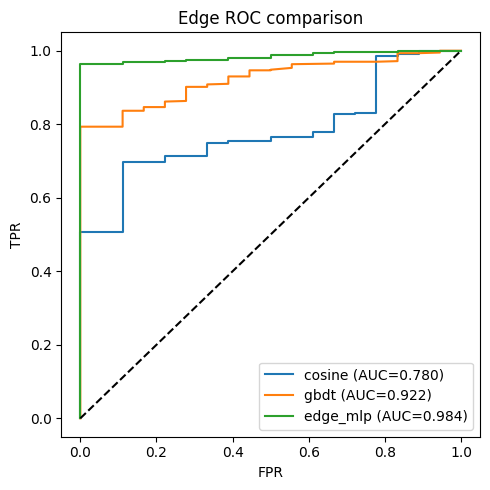

In [16]:
def main():
    Z, y, scenes = load_all_embeddings(CACHE_ROOT)
    print("Images:", len(Z), "Scenes:", len(scenes))

    train_idx, val_idx = split_images(len(Z), VAL_RATIO, SEED)

    edges = build_edge_table(Z, y, K)
    edges_tr = edges[edges["i"].isin(train_idx) & edges["j"].isin(train_idx)].reset_index(drop=True)
    edges_va = edges[edges["i"].isin(val_idx) & edges["j"].isin(val_idx)].reset_index(drop=True)

    def pos_available_rate(edges: pd.DataFrame) -> float:
        # fraction of anchors i that have at least one positive candidate
        has_pos = edges.groupby("i")["same_scene"].max()
        return float(has_pos.mean())

    print(
        "Val anchors with any positive candidate:",
        pos_available_rate(edges_va),
    )

    # heuristic
    score_cos = edges_va["cos"].to_numpy()

    # GBDT 
    gbdt = train_gbdt(edges_tr)
    score_gbdt = gbdt.predict_proba(make_X(edges_va))[:, 1]

    # EdgeMLP 
    model = EdgeMLP(Z.shape[1]).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    loss_fn = nn.BCELoss()

    Zt = torch.from_numpy(Z).to(DEVICE)
    i_tr = torch.from_numpy(edges_tr["i"].to_numpy()).to(DEVICE)
    j_tr = torch.from_numpy(edges_tr["j"].to_numpy()).to(DEVICE)
    y_tr = torch.from_numpy(edges_tr["same_scene"].to_numpy()).float().to(DEVICE)

    for epoch in range(EPOCHS):
        perm = torch.randperm(len(i_tr))
        for b in range(0, len(i_tr), BATCH_SIZE):
            idx = perm[b : b + BATCH_SIZE]
            pred = model(Zt[i_tr[idx]], Zt[j_tr[idx]])
            loss = loss_fn(pred, y_tr[idx])
            opt.zero_grad()
            loss.backward()
            opt.step()
        print(f"Epoch {epoch+1:02d} | EdgeMLP loss {loss.item():.4f}")

    model.eval()
    with torch.no_grad():
        score_mlp = (
            model(
                Zt[edges_va["i"].to_numpy()],
                Zt[edges_va["j"].to_numpy()],
            )
            .cpu()
            .numpy()
        )

    # evaluation 
    yva = edges_va["same_scene"].to_numpy()

    results = []
    for name, score in [
        ("cosine", score_cos),
        ("gbdt", score_gbdt),
        ("edge_mlp", score_mlp),
    ]:
        results.append(
        {
            "model": name,
            "auc": roc_auc_score(yva, score),
            "ap": average_precision_score(yva, score),
            "r@1": edge_recall_at_k(edges_va, score, K=1),
            "r@3": edge_recall_at_k(edges_va, score, K=3),
            "r@5": edge_recall_at_k(edges_va, score, K=5)
        }
    )

    df = pd.DataFrame(results)
    print(df)

    plot_roc(
        yva,
        {
            "cosine": score_cos,
            "gbdt": score_gbdt,
            "edge_mlp": score_mlp,
        },
    )

    # saving results
    joblib.dump(
        {
            "gbdt": gbdt,
            "K": K,
        },
        OUT_ROOT / "edge_gbdt.joblib",
    )

    torch.save(
        {
            "state_dict": model.state_dict(),
            "dim": Z.shape[1],
            "K": K,
        },
        OUT_ROOT / "edge_mlp.pt",
    )

    df.to_csv(OUT_ROOT / "comparison_metrics.csv", index=False)

if __name__ == "__main__":
    main()